# 🏋️ Squat Posture Classifier — Final Edition
**Train on your Drive video dataset → Test live with your webcam**

Architecture: `1D CNN → BiLSTM → Multi-Head Self-Attention`
Camera invariance: 3-D skeleton rotation + joint-angle features + Y-axis augmentation

---
### Steps
1. Run **Cell 1** (Install) → **Restart Runtime** → continue from Cell 2
2. **Cell 3** — set your Google Drive dataset path
3. **Cells 4–12** — build dataset, train, evaluate, export TFLite
4. **Cell 14** — open live webcam, click ▶ START and squat!

## Cell 1 — Install dependencies
> ⚠️ **Restart the runtime after running this cell.**

In [ ]:
!pip install -q "mediapipe==0.10.14" tensorflow scikit-learn matplotlib seaborn tqdm


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.7/35.7 MB 37.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.2/295.2 kB 25.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grain 0.2.16 requires protobuf>=5.28.3, but you have protobuf 4.25.9 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 4.25.9 which is incompatible.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 4.25.9 which is incompatible.
opentelemetry-proto 1.38.0 requires protobuf<7.0,>=5.0, but you have protobuf 4.25.9 which is incompatible.


## Cell 2 — Imports

In [ ]:
import os, cv2, math, json, pickle, time, warnings, itertools
from base64 import b64decode, b64encode
import numpy as np

# MediaPipe — explicit imports to avoid mp.solutions attribute error
import mediapipe as mp
from mediapipe.python.solutions import pose as _mp_pose_module
from mediapipe.python.solutions import drawing_utils as _mp_drawing
from mediapipe.python.solutions import drawing_styles as _mp_styles

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, regularizers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from IPython.display import display, Javascript, HTML
from google.colab.output import eval_js
from google.colab import output, drive

warnings.filterwarnings("ignore")
tf.get_logger().setLevel("ERROR")
print(f"TensorFlow : {tf.__version__}")
print(f"MediaPipe  : {mp.__version__}")
print(f"GPU        : {tf.config.list_physical_devices(chr(71)+chr(80)+chr(85))}")


TensorFlow : 2.19.0
MediaPipe  : 0.10.14
GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Cell 3 — ⚙️ CONFIG  ← Edit your Drive paths here

In [ ]:
drive.mount('/content/drive')

# ── ▼ SET THESE ▼ ─────────────────────────────────────────────────────────
DATASET_ROOT = '/content/drive/MyDrive/DataSets/Squats'     # folder with 5 sub-folders
OUTPUT_DIR   = '/content/drive/MyDrive/DataSets/Squats_final'
# ── ▲ SET THESE ▲ ─────────────────────────────────────────────────────────

CLASS_NAMES = [
    'Incorrect Posture',
    'Legs too Narrow',
    'Legs too Wide',
    'Not a Squat',
    'Perfect Squats',
]
NUM_CLASSES = len(CLASS_NAMES)

WINDOW_SIZE   = 45   # frames per sample (~1 s at 30 fps)
STRIDE        = 12     # sliding-window stride
TARGET_FPS    = 30
MAX_FRAMES    = 300
AUG_ROTATIONS = [-45, -30, -15, 0, 15, 30, 45]
AUG_NOISE_STD = 0.012

os.makedirs(OUTPUT_DIR, exist_ok=True)
print("Dataset :", DATASET_ROOT)
print("Output  :", OUTPUT_DIR)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset : /content/drive/MyDrive/DataSets/Squats
Output  : /content/drive/MyDrive/DataSets/Squats_final


## Cell 4 — Landmark definitions
Elbows / wrists / hands (landmarks 13–22) are excluded as required.

Normal 8 angles


In [ ]:
# Elbows/wrists/hands (13-22) excluded per requirement
KEPT_LM = [11, 12, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32]
_i = {lm: idx for idx, lm in enumerate(KEPT_LM)}

L_SHOULDER = _i[11]; R_SHOULDER = _i[12]
L_HIP      = _i[23]; R_HIP      = _i[24]
L_KNEE     = _i[25]; R_KNEE     = _i[26]
L_ANKLE    = _i[27]; R_ANKLE    = _i[28]
L_HEEL     = _i[29]; R_HEEL     = _i[30]
L_FOOT     = _i[31]; R_FOOT     = _i[32]

N_KEPT    = len(KEPT_LM)             # 12
COORD_DIM = N_KEPT * 4               # 48
ANGLE_DIM = 8
FEAT_DIM  = COORD_DIM + ANGLE_DIM   # 56

print(f"Features per frame : {FEAT_DIM}  ({COORD_DIM} coords + {ANGLE_DIM} angles)")
print(f"Model input shape  : ({WINDOW_SIZE}, {FEAT_DIM})")


Features per frame : 56  (48 coords + 8 angles)
Model input shape  : (45, 56)


10 angles

In [ ]:
# Elbows/wrists/hands (13-22) excluded per requirement
KEPT_LM = [11, 12, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32]
_i = {lm: idx for idx, lm in enumerate(KEPT_LM)}

L_SHOULDER = _i[11]; R_SHOULDER = _i[12]
L_HIP      = _i[23]; R_HIP      = _i[24]
L_KNEE     = _i[25]; R_KNEE     = _i[26]
L_ANKLE    = _i[27]; R_ANKLE    = _i[28]
L_HEEL     = _i[29]; R_HEEL     = _i[30]
L_FOOT     = _i[31]; R_FOOT     = _i[32]

N_KEPT    = len(KEPT_LM)             # 12
COORD_DIM = N_KEPT * 4               # 48
ANGLE_DIM = 10                       # was 8, added knee-tracking + hip-symmetry
FEAT_DIM  = COORD_DIM + ANGLE_DIM   # 58

print(f"Features per frame : {FEAT_DIM}  ({COORD_DIM} coords + {ANGLE_DIM} angles)")
print(f"Model input shape  : ({WINDOW_SIZE}, {FEAT_DIM})")

Features per frame : 58  (48 coords + 10 angles)
Model input shape  : (30, 58)


only angles


In [ ]:
KEPT_LM = [11, 12, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32]
_i = {lm: idx for idx, lm in enumerate(KEPT_LM)}

L_SHOULDER = _i[11]; R_SHOULDER = _i[12]
L_HIP      = _i[23]; R_HIP      = _i[24]
L_KNEE     = _i[25]; R_KNEE     = _i[26]
L_ANKLE    = _i[27]; R_ANKLE    = _i[28]
L_HEEL     = _i[29]; R_HEEL     = _i[30]
L_FOOT     = _i[31]; R_FOOT     = _i[32]

N_KEPT    = len(KEPT_LM)   # 12
COORD_DIM = N_KEPT * 4     # 48 — kept for augmentation math, NOT fed to model
ANGLE_DIM = 10
FEAT_DIM  = ANGLE_DIM      # 10 — model only sees angles

print(f"Features per frame : {FEAT_DIM}  (angles only)")
print(f"Model input shape  : ({WINDOW_SIZE}, {FEAT_DIM})")

Features per frame : 10  (angles only)
Model input shape  : (45, 10)


## Cell 5 — Geometry helpers & camera-angle-proof normalisation

**How camera invariance works:**
1. Translate skeleton to hip-centre
2. Y-axis rotate so L→R hip always points to `+X` (cancels camera horizontal angle)
3. Scale by torso height (cancels distance / zoom)
4. Append 8 joint angles — mathematically rotation-invariant

8 angles

In [ ]:
def vec3(arr, idx):
    return arr[idx, :3]

def angle_between(a, b, c):
    ba, bc = a - b, c - b
    cos_v = np.dot(ba, bc) / (np.linalg.norm(ba) * np.linalg.norm(bc) + 1e-8)
    return math.degrees(math.acos(float(np.clip(cos_v, -1, 1))))

def angle_from_vertical(v):
    down = np.array([0., -1., 0.])
    cos_v = np.dot(v, down) / (np.linalg.norm(v) * np.linalg.norm(down) + 1e-8)
    return math.degrees(math.acos(float(np.clip(cos_v, -1, 1))))

def compute_joint_angles(arr) -> np.ndarray:
    """8 biomechanical angles — invariant to camera rotation."""
    lk = angle_between(vec3(arr,L_HIP),      vec3(arr,L_KNEE),   vec3(arr,L_ANKLE))
    rk = angle_between(vec3(arr,R_HIP),      vec3(arr,R_KNEE),   vec3(arr,R_ANKLE))
    lh = angle_between(vec3(arr,L_SHOULDER), vec3(arr,L_HIP),    vec3(arr,L_KNEE))
    rh = angle_between(vec3(arr,R_SHOULDER), vec3(arr,R_HIP),    vec3(arr,R_KNEE))
    la = angle_between(vec3(arr,L_KNEE),     vec3(arr,L_ANKLE),  vec3(arr,L_HEEL))
    ra = angle_between(vec3(arr,R_KNEE),     vec3(arr,R_ANKLE),  vec3(arr,R_HEEL))
    spine = (vec3(arr,L_SHOULDER) + vec3(arr,R_SHOULDER)) / 2.
    tl = angle_from_vertical(spine)
    foot_w = np.linalg.norm(vec3(arr,L_FOOT) - vec3(arr,R_FOOT))
    hip_w  = np.linalg.norm(vec3(arr,L_HIP)  - vec3(arr,R_HIP)) + 1e-8
    fw = float(np.clip(foot_w / hip_w, 0, 3)) / 3. * 180.
    return np.array([lk, rk, lh, rh, la, ra, tl, fw], dtype=np.float32) / 180.

def normalise_skeleton(raw: np.ndarray) -> np.ndarray:
    arr = raw.copy().astype(np.float32)
    hip_c = (arr[L_HIP,:3] + arr[R_HIP,:3]) / 2.
    arr[:,:3] -= hip_c
    hip_vec = arr[R_HIP,:3] - arr[L_HIP,:3]
    hip_xz  = np.array([hip_vec[0], 0., hip_vec[2]], dtype=np.float32)
    mag = np.linalg.norm(hip_xz)
    if mag > 1e-6:
        hip_xz /= mag
        ct, st = float(hip_xz[0]), float(hip_xz[2])
        Ry = np.array([[ct,0.,st],[0.,1.,0.],[-st,0.,ct]], dtype=np.float32)
        arr[:,:3] = (Ry @ arr[:,:3].T).T
    sc = (arr[L_SHOULDER,:3] + arr[R_SHOULDER,:3]) / 2.
    arr[:,:3] /= (np.linalg.norm(sc) + 1e-8)
    return arr

def frame_to_feature(arr: np.ndarray) -> np.ndarray:
    return np.concatenate([arr.flatten(), compute_joint_angles(arr)])

def rotate_y(arr: np.ndarray, degrees: float) -> np.ndarray:
    t = math.radians(degrees)
    ct, st = math.cos(t), math.sin(t)
    Ry = np.array([[ct,0.,st],[0.,1.,0.],[-st,0.,ct]], dtype=np.float32)
    out = arr.copy(); out[:,:3] = (Ry @ arr[:,:3].T).T
    return out

print("Geometry helpers ✓")


Geometry helpers ✓


10 angles

In [ ]:
def vec3(arr, idx):
    return arr[idx, :3]

def angle_between(a, b, c):
    ba, bc = a - b, c - b
    cos_v = np.dot(ba, bc) / (np.linalg.norm(ba) * np.linalg.norm(bc) + 1e-8)
    return math.degrees(math.acos(float(np.clip(cos_v, -1, 1))))

def angle_from_vertical(v):
    down = np.array([0., -1., 0.])
    cos_v = np.dot(v, down) / (np.linalg.norm(v) * np.linalg.norm(down) + 1e-8)
    return math.degrees(math.acos(float(np.clip(cos_v, -1, 1))))

def compute_joint_angles(arr) -> np.ndarray:
    """10 biomechanical angles — invariant to camera rotation."""
    lk = angle_between(vec3(arr,L_HIP),      vec3(arr,L_KNEE),   vec3(arr,L_ANKLE))
    rk = angle_between(vec3(arr,R_HIP),      vec3(arr,R_KNEE),   vec3(arr,R_ANKLE))
    lh = angle_between(vec3(arr,L_SHOULDER), vec3(arr,L_HIP),    vec3(arr,L_KNEE))
    rh = angle_between(vec3(arr,R_SHOULDER), vec3(arr,R_HIP),    vec3(arr,R_KNEE))
    la = angle_between(vec3(arr,L_KNEE),     vec3(arr,L_ANKLE),  vec3(arr,L_HEEL))
    ra = angle_between(vec3(arr,R_KNEE),     vec3(arr,R_ANKLE),  vec3(arr,R_HEEL))
    spine = (vec3(arr,L_SHOULDER) + vec3(arr,R_SHOULDER)) / 2.
    tl = angle_from_vertical(spine)
    foot_w = np.linalg.norm(vec3(arr,L_FOOT) - vec3(arr,R_FOOT))
    hip_w  = np.linalg.norm(vec3(arr,L_HIP)  - vec3(arr,R_HIP)) + 1e-8
    fw = float(np.clip(foot_w / hip_w, 0, 3)) / 3. * 180.

    # NEW: knee tracking — catches knees caving in vs bowing out
    knee_w  = np.linalg.norm(vec3(arr,L_KNEE)  - vec3(arr,R_KNEE))
    ankle_w = np.linalg.norm(vec3(arr,L_ANKLE) - vec3(arr,R_ANKLE)) + 1e-8
    ktr = float(np.clip(knee_w / ankle_w, 0, 3)) / 3. * 180.

    # NEW: hip symmetry — catches leaning to one side
    hip_sym = float(abs(vec3(arr,L_HIP)[1] - vec3(arr,R_HIP)[1])) * 180.

    return np.array([lk, rk, lh, rh, la, ra, tl, fw, ktr, hip_sym],
                    dtype=np.float32) / 180.

def normalise_skeleton(raw: np.ndarray) -> np.ndarray:
    arr = raw.copy().astype(np.float32)
    hip_c = (arr[L_HIP,:3] + arr[R_HIP,:3]) / 2.
    arr[:,:3] -= hip_c
    hip_vec = arr[R_HIP,:3] - arr[L_HIP,:3]
    hip_xz  = np.array([hip_vec[0], 0., hip_vec[2]], dtype=np.float32)
    mag = np.linalg.norm(hip_xz)
    if mag > 1e-6:
        hip_xz /= mag
        ct, st = float(hip_xz[0]), float(hip_xz[2])
        Ry = np.array([[ct,0.,st],[0.,1.,0.],[-st,0.,ct]], dtype=np.float32)
        arr[:,:3] = (Ry @ arr[:,:3].T).T
    sc = (arr[L_SHOULDER,:3] + arr[R_SHOULDER,:3]) / 2.
    arr[:,:3] /= (np.linalg.norm(sc) + 1e-8)
    return arr

def frame_to_feature(arr: np.ndarray) -> np.ndarray:
    return np.concatenate([arr.flatten(), compute_joint_angles(arr)])

def rotate_y(arr: np.ndarray, degrees: float) -> np.ndarray:
    t = math.radians(degrees)
    ct, st = math.cos(t), math.sin(t)
    Ry = np.array([[ct,0.,st],[0.,1.,0.],[-st,0.,ct]], dtype=np.float32)
    out = arr.copy(); out[:,:3] = (Ry @ arr[:,:3].T).T
    return out

print("Geometry helpers ✓")

Geometry helpers ✓


only angles

In [ ]:
def vec3(arr, idx):
    return arr[idx, :3]

def angle_between(a, b, c):
    ba, bc = a - b, c - b
    cos_v = np.dot(ba, bc) / (np.linalg.norm(ba) * np.linalg.norm(bc) + 1e-8)
    return math.degrees(math.acos(float(np.clip(cos_v, -1, 1))))

def angle_from_vertical(v):
    down = np.array([0., -1., 0.])
    cos_v = np.dot(v, down) / (np.linalg.norm(v) * np.linalg.norm(down) + 1e-8)
    return math.degrees(math.acos(float(np.clip(cos_v, -1, 1))))

def compute_joint_angles(arr) -> np.ndarray:
    """10 biomechanical angles — fully camera invariant."""
    lk = angle_between(vec3(arr,L_HIP),      vec3(arr,L_KNEE),   vec3(arr,L_ANKLE))
    rk = angle_between(vec3(arr,R_HIP),      vec3(arr,R_KNEE),   vec3(arr,R_ANKLE))
    lh = angle_between(vec3(arr,L_SHOULDER), vec3(arr,L_HIP),    vec3(arr,L_KNEE))
    rh = angle_between(vec3(arr,R_SHOULDER), vec3(arr,R_HIP),    vec3(arr,R_KNEE))
    la = angle_between(vec3(arr,L_KNEE),     vec3(arr,L_ANKLE),  vec3(arr,L_HEEL))
    ra = angle_between(vec3(arr,R_KNEE),     vec3(arr,R_ANKLE),  vec3(arr,R_HEEL))
    spine = (vec3(arr,L_SHOULDER) + vec3(arr,R_SHOULDER)) / 2.
    tl = angle_from_vertical(spine)
    foot_w = np.linalg.norm(vec3(arr,L_FOOT) - vec3(arr,R_FOOT))
    hip_w  = np.linalg.norm(vec3(arr,L_HIP)  - vec3(arr,R_HIP)) + 1e-8
    fw = float(np.clip(foot_w / hip_w, 0, 3)) / 3. * 180.
    knee_w  = np.linalg.norm(vec3(arr,L_KNEE)  - vec3(arr,R_KNEE))
    ankle_w = np.linalg.norm(vec3(arr,L_ANKLE) - vec3(arr,R_ANKLE)) + 1e-8
    ktr = float(np.clip(knee_w / ankle_w, 0, 3)) / 3. * 180.
    hip_sym = float(abs(vec3(arr,L_HIP)[1] - vec3(arr,R_HIP)[1])) * 180.
    return np.array([lk, rk, lh, rh, la, ra, tl, fw, ktr, hip_sym],
                    dtype=np.float32) / 180.

def normalise_skeleton(raw: np.ndarray) -> np.ndarray:
    arr = raw.copy().astype(np.float32)
    hip_c = (arr[L_HIP,:3] + arr[R_HIP,:3]) / 2.
    arr[:,:3] -= hip_c
    hip_vec = arr[R_HIP,:3] - arr[L_HIP,:3]
    hip_xz  = np.array([hip_vec[0], 0., hip_vec[2]], dtype=np.float32)
    mag = np.linalg.norm(hip_xz)
    if mag > 1e-6:
        hip_xz /= mag
        ct, st = float(hip_xz[0]), float(hip_xz[2])
        Ry = np.array([[ct,0.,st],[0.,1.,0.],[-st,0.,ct]], dtype=np.float32)
        arr[:,:3] = (Ry @ arr[:,:3].T).T
    sc = (arr[L_SHOULDER,:3] + arr[R_SHOULDER,:3]) / 2.
    arr[:,:3] /= (np.linalg.norm(sc) + 1e-8)
    return arr

def frame_to_feature(arr: np.ndarray) -> np.ndarray:
    # angles only — coords used internally for angle math but not returned
    return compute_joint_angles(arr)

def rotate_y(arr: np.ndarray, degrees: float) -> np.ndarray:
    t = math.radians(degrees)
    ct, st = math.cos(t), math.sin(t)
    Ry = np.array([[ct,0.,st],[0.,1.,0.],[-st,0.,ct]], dtype=np.float32)
    out = arr.copy(); out[:,:3] = (Ry @ arr[:,:3].T).T
    return out

print("Geometry helpers ✓")

Geometry helpers ✓


## Cell 6 — Video processing & augmentation pipeline

8 angles

In [ ]:
def extract_frames_from_video(path, pose_detector):
    cap = cv2.VideoCapture(path)
    if not cap.isOpened(): return []
    src_fps  = cap.get(cv2.CAP_PROP_FPS) or 30.
    interval = max(1, round(src_fps / TARGET_FPS))
    frames, fidx = [], 0
    while len(frames) < MAX_FRAMES:
        ret, frame = cap.read()
        if not ret: break
        if fidx % interval == 0:
            rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            res = pose_detector.process(rgb)
            if res.pose_landmarks:
                lm  = res.pose_landmarks.landmark
                raw = np.array([[lm[i].x, lm[i].y, lm[i].z, lm[i].visibility]
                                for i in KEPT_LM], dtype=np.float32)
                if raw[[L_HIP,R_HIP,L_KNEE,R_KNEE],3].min() >= 0.40:
                    frames.append(frame_to_feature(normalise_skeleton(raw)))
        fidx += 1
    cap.release()
    return frames

def sliding_windows(frames):
    if not frames: return []
    arr = np.stack(frames)
    if len(arr) < WINDOW_SIZE:
        arr = np.vstack([np.zeros((WINDOW_SIZE-len(arr), FEAT_DIM), dtype=np.float32), arr])
    return [arr[s:s+WINDOW_SIZE] for s in range(0, len(arr)-WINDOW_SIZE+1, STRIDE)]

def augment_window(win):
    T          = win.shape[0]
    coord_part = win[:, :COORD_DIM].reshape(T, N_KEPT, 4)
    augmented  = []

    # existing augmentations ...
    for deg in AUG_ROTATIONS:
        rot = np.stack([rotate_y(coord_part[t], deg) for t in range(T)])
        rot += np.random.normal(0, AUG_NOISE_STD, rot.shape).astype(np.float32)
        augmented.append(np.stack([frame_to_feature(rot[t]) for t in range(T)]))

    noisy = coord_part + np.random.normal(0, AUG_NOISE_STD, coord_part.shape).astype(np.float32)
    augmented.append(np.stack([frame_to_feature(noisy[t]) for t in range(T)]))

    # NEW: foot width scale jitter — simulates different camera distances
    for foot_scale in [0.80, 0.90, 1.10, 1.20]:
        scaled_c = coord_part.copy()
        # only scale the foot and ankle landmarks laterally (X axis)
        for lm_idx in [L_FOOT, R_FOOT, L_ANKLE, R_ANKLE]:
            scaled_c[:, lm_idx, 0] *= foot_scale
        augmented.append(np.stack([frame_to_feature(scaled_c[t]) for t in range(T)]))

    # NEW: left-right mirror
    LR_SWAP = [1,0, 3,2, 5,4, 7,6, 9,8, 11,10]
    mirrored = coord_part[:, LR_SWAP, :].copy()
    mirrored[:, :, 0] *= -1
    augmented.append(np.stack([frame_to_feature(mirrored[t]) for t in range(T)]))

    # NEW: speed jitter
    for speed_factor in [0.80, 1.20]:
        new_indices = np.linspace(0, T-1, int(T * speed_factor)).astype(int)
        sped = coord_part[new_indices]
        if len(sped) >= T:
            sped = sped[:T]
        else:
            pad  = np.zeros((T - len(sped), N_KEPT, 4), dtype=np.float32)
            sped = np.vstack([pad, sped])
        augmented.append(np.stack([frame_to_feature(sped[t]) for t in range(T)]))

    return augmented

print("Video pipeline ✓")


Video pipeline ✓


10 angles

In [ ]:
def extract_frames_from_video(path, pose_detector):
    cap = cv2.VideoCapture(path)
    if not cap.isOpened(): return []
    src_fps  = cap.get(cv2.CAP_PROP_FPS) or 30.
    interval = max(1, round(src_fps / TARGET_FPS))
    frames, fidx = [], 0
    while len(frames) < MAX_FRAMES:
        ret, frame = cap.read()
        if not ret: break
        if fidx % interval == 0:
            rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            res = pose_detector.process(rgb)
            if res.pose_landmarks:
                lm  = res.pose_landmarks.landmark
                raw = np.array([[lm[i].x, lm[i].y, lm[i].z, lm[i].visibility]
                                for i in KEPT_LM], dtype=np.float32)
                if raw[[L_HIP,R_HIP,L_KNEE,R_KNEE],3].min() >= 0.40:
                    frames.append(frame_to_feature(normalise_skeleton(raw)))
        fidx += 1
    cap.release()
    return frames

def sliding_windows(frames):
    if not frames: return []
    arr = np.stack(frames)
    if len(arr) < WINDOW_SIZE:
        arr = np.vstack([np.zeros((WINDOW_SIZE-len(arr), FEAT_DIM), dtype=np.float32), arr])
    return [arr[s:s+WINDOW_SIZE] for s in range(0, len(arr)-WINDOW_SIZE+1, STRIDE)]

def augment_window(win):
    T          = win.shape[0]
    coord_part = win[:, :COORD_DIM].reshape(T, N_KEPT, 4)
    augmented  = []

    # Y-axis rotations
    for deg in AUG_ROTATIONS:
        rot = np.stack([rotate_y(coord_part[t], deg) for t in range(T)])
        rot += np.random.normal(0, AUG_NOISE_STD, rot.shape).astype(np.float32)
        augmented.append(np.stack([frame_to_feature(rot[t]) for t in range(T)]))

    # Noise only
    noisy = coord_part + np.random.normal(0, AUG_NOISE_STD, coord_part.shape).astype(np.float32)
    augmented.append(np.stack([frame_to_feature(noisy[t]) for t in range(T)]))

    # Left-right mirror
    LR_SWAP = [1,0, 3,2, 5,4, 7,6, 9,8, 11,10]
    mirrored = coord_part[:, LR_SWAP, :].copy()
    mirrored[:, :, 0] *= -1
    augmented.append(np.stack([frame_to_feature(mirrored[t]) for t in range(T)]))

    # Speed jitter
    for speed_factor in [0.80, 1.20]:
        new_indices = np.linspace(0, T-1, int(T * speed_factor)).astype(int)
        sped = coord_part[new_indices]
        if len(sped) >= T:
            sped = sped[:T]
        else:
            pad  = np.zeros((T - len(sped), N_KEPT, 4), dtype=np.float32)
            sped = np.vstack([pad, sped])
        augmented.append(np.stack([frame_to_feature(sped[t]) for t in range(T)]))

    # Foot width jitter — simulates different camera distances
    for foot_scale in [0.80, 0.90, 1.10, 1.20]:
        fc = coord_part.copy()
        for lm_idx in [L_FOOT, R_FOOT, L_ANKLE, R_ANKLE]:
            fc[:, lm_idx, 0] *= foot_scale
        augmented.append(np.stack([frame_to_feature(fc[t]) for t in range(T)]))

    # Scale jitter — person closer/farther from camera
    for scale in [0.85, 1.15]:
        sc = coord_part.copy()
        sc[:, :, :3] *= scale
        augmented.append(np.stack([frame_to_feature(sc[t]) for t in range(T)]))

    return augmented

print("Video pipeline ✓")

Video pipeline ✓


only angles

In [ ]:
def extract_frames_from_video(path, pose_detector):
    cap = cv2.VideoCapture(path)
    if not cap.isOpened(): return []
    src_fps  = cap.get(cv2.CAP_PROP_FPS) or 30.
    interval = max(1, round(src_fps / TARGET_FPS))
    frames, fidx = [], 0
    while len(frames) < MAX_FRAMES:
        ret, frame = cap.read()
        if not ret: break
        if fidx % interval == 0:
            rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            res = pose_detector.process(rgb)
            if res.pose_landmarks:
                lm  = res.pose_landmarks.landmark
                raw = np.array([[lm[i].x, lm[i].y, lm[i].z, lm[i].visibility]
                                for i in KEPT_LM], dtype=np.float32)
                if raw[[L_HIP,R_HIP,L_KNEE,R_KNEE],3].min() >= 0.40:
                    raw_frames.append(normalise_skeleton(raw))  # store raw coords
        fidx += 1
    cap.release()
    return frames

def sliding_windows(frames):
    if not frames: return []
    arr = np.stack(frames)
    if len(arr) < WINDOW_SIZE:
        arr = np.vstack([np.zeros((WINDOW_SIZE-len(arr), FEAT_DIM), dtype=np.float32), arr])
    return [arr[s:s+WINDOW_SIZE] for s in range(0, len(arr)-WINDOW_SIZE+1, STRIDE)]

def process_videos(video_paths, labels, pose_detector, augment=False):
    X_all, y_all = [], []

    for vpath, label in tqdm(zip(video_paths, labels), total=len(video_paths)):
        cap = cv2.VideoCapture(vpath)
        if not cap.isOpened(): continue
        src_fps  = cap.get(cv2.CAP_PROP_FPS) or 30.
        interval = max(1, round(src_fps / TARGET_FPS))
        raw_frames, fidx = [], 0

        while len(raw_frames) < MAX_FRAMES:
            ret, frame = cap.read()
            if not ret: break
            if fidx % interval == 0:
                rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                res = pose_detector.process(rgb)
                if res.pose_landmarks:
                    lm  = res.pose_landmarks.landmark
                    raw = np.array([[lm[i].x, lm[i].y, lm[i].z, lm[i].visibility]
                                    for i in KEPT_LM], dtype=np.float32)
                    if raw[[L_HIP,R_HIP,L_KNEE,R_KNEE],3].min() >= 0.40:
                        raw_frames.append(normalise_skeleton(raw))  # (12, 4) coords
            fidx += 1
        cap.release()

        if len(raw_frames) < WINDOW_SIZE:
            continue

        raw_arr = np.stack(raw_frames)  # (num_frames, 12, 4)

        # Sliding windows on raw coords
        coord_windows = [raw_arr[s:s+WINDOW_SIZE]
                         for s in range(0, len(raw_arr)-WINDOW_SIZE+1, STRIDE)]

        for cwin in coord_windows:
            # ── Base sample ───────────────────────────────────────────────
            angle_win = np.stack([frame_to_feature(cwin[t]) for t in range(WINDOW_SIZE)])
            X_all.append(angle_win)
            y_all.append(label)

            if not augment:
                continue

            # ── 1. Y-axis rotations (camera horizontal angle) ─────────────
            for deg in AUG_ROTATIONS:
                rot = np.stack([rotate_y(cwin[t], deg) for t in range(WINDOW_SIZE)])
                rot += np.random.normal(0, AUG_NOISE_STD, rot.shape).astype(np.float32)
                X_all.append(np.stack([frame_to_feature(rot[t]) for t in range(WINDOW_SIZE)]))
                y_all.append(label)

            # ── 2. Coord noise (small body movement variation) ────────────
            noisy_c = cwin + np.random.normal(0, AUG_NOISE_STD, cwin.shape).astype(np.float32)
            X_all.append(np.stack([frame_to_feature(noisy_c[t]) for t in range(WINDOW_SIZE)]))
            y_all.append(label)

            # ── 3. Left-right mirror (person facing other direction) ───────
            LR_SWAP = [1,0, 3,2, 5,4, 7,6, 9,8, 11,10]
            mirrored = cwin[:, LR_SWAP, :].copy()
            mirrored[:, :, 0] *= -1
            X_all.append(np.stack([frame_to_feature(mirrored[t]) for t in range(WINDOW_SIZE)]))
            y_all.append(label)

            # ── 4. Speed jitter (faster/slower squat) ─────────────────────
            for speed_factor in [0.75, 0.85, 1.15, 1.25]:
                new_idx = np.linspace(0, WINDOW_SIZE-1,
                                      int(WINDOW_SIZE * speed_factor)).astype(int)
                sped = cwin[new_idx]
                if len(sped) >= WINDOW_SIZE:
                    sped = sped[:WINDOW_SIZE]
                else:
                    pad  = np.zeros((WINDOW_SIZE - len(sped), N_KEPT, 4), dtype=np.float32)
                    sped = np.vstack([pad, sped])
                X_all.append(np.stack([frame_to_feature(sped[t]) for t in range(WINDOW_SIZE)]))
                y_all.append(label)

            # ── 5. Foot width jitter (camera distance variation) ───────────
            for foot_scale in [0.75, 0.85, 0.90, 1.10, 1.15, 1.25]:
                fc = cwin.copy()
                for lm_idx in [L_FOOT, R_FOOT, L_ANKLE, R_ANKLE]:
                    fc[:, lm_idx, 0] *= foot_scale
                X_all.append(np.stack([frame_to_feature(fc[t]) for t in range(WINDOW_SIZE)]))
                y_all.append(label)

            # ── 6. Global scale jitter (person closer/farther) ────────────
            for scale in [0.80, 0.90, 1.10, 1.20]:
                sc = cwin.copy()
                sc[:, :, :3] *= scale
                X_all.append(np.stack([frame_to_feature(sc[t]) for t in range(WINDOW_SIZE)]))
                y_all.append(label)

            # ── 7. Angle noise (simulates MediaPipe webcam jitter) ─────────
            base_angles = np.stack([frame_to_feature(cwin[t]) for t in range(WINDOW_SIZE)])
            for noise_level in [0.01, 0.02, 0.03, 0.04]:
                noisy_a = base_angles + np.random.normal(
                              0, noise_level, base_angles.shape).astype(np.float32)
                noisy_a = np.clip(noisy_a, 0, 1)
                X_all.append(noisy_a)
                y_all.append(label)

            # ── 8. Temporal dropout (simulates dropped/occluded frames) ───
            for _ in range(2):   # 2 random versions
                dropped = base_angles.copy()
                n_drop  = np.random.randint(1, 4)
                drop_idx = np.random.choice(WINDOW_SIZE, n_drop, replace=False)
                dropped[drop_idx] = 0.
                X_all.append(dropped)
                y_all.append(label)

            # ── 9. Time reversal (standing up vs sitting down motion) ──────
            reversed_win = cwin[::-1].copy()
            X_all.append(np.stack([frame_to_feature(reversed_win[t])
                                   for t in range(WINDOW_SIZE)]))
            y_all.append(label)

    return np.array(X_all, dtype=np.float32), np.array(y_all, dtype=np.int32)

print("Video pipeline ✓")

Video pipeline ✓


## Cell 7 — Build dataset from your Drive video folders
⏳ This will take a few minutes depending on how many videos you have.

In [ ]:
def get_video_paths(root, class_names):
    EXTS = {'.mp4','.mov','.avi','.mkv','.webm','.m4v'}
    paths, labels = [], []
    for label_idx, cls in enumerate(class_names):
        cls_dir = os.path.join(root, cls)
        if not os.path.isdir(cls_dir):
            for d in os.listdir(root):
                if d.lower() == cls.lower():
                    cls_dir = os.path.join(root, d); break
        if not os.path.isdir(cls_dir):
            print(f"[WARN] Missing: {cls_dir}"); continue
        vids = [os.path.join(cls_dir, f) for f in os.listdir(cls_dir)
                if os.path.splitext(f)[1].lower() in EXTS]
        paths.extend(vids)
        labels.extend([label_idx] * len(vids))
        print(f"  [{label_idx}] {cls} — {len(vids)} videos")
    return paths, labels

# Collect all video paths
print("Scanning video folders…")
all_paths, all_labels = get_video_paths(DATASET_ROOT, CLASS_NAMES)
all_paths  = np.array(all_paths)
all_labels = np.array(all_labels)
print(f"\nTotal videos: {len(all_paths)}")

# Split at VIDEO level — before any window extraction
from sklearn.model_selection import train_test_split as _tsplit

tmp_paths,  test_paths,  tmp_labels,  test_labels  = _tsplit(
    all_paths, all_labels, test_size=0.15, stratify=all_labels, random_state=42)
train_paths, val_paths, train_labels, val_labels    = _tsplit(
    tmp_paths, tmp_labels, test_size=0.176, stratify=tmp_labels, random_state=42)

print(f"Train videos : {len(train_paths)}")
print(f"Val videos   : {len(val_paths)}")
print(f"Test videos  : {len(test_paths)}")

# Process each split separately
pose = _mp_pose_module.Pose(
    static_image_mode=False, model_complexity=1,
    smooth_landmarks=True,
    min_detection_confidence=0.45, min_tracking_confidence=0.45)

print("\nProcessing train videos (with augmentation)…")
X_train, y_train = process_videos(train_paths, train_labels, pose, augment=True)

print("\nProcessing val videos (no augmentation)…")
X_val, y_val     = process_videos(val_paths,   val_labels,   pose, augment=False)

print("\nProcessing test videos (no augmentation)…")
X_test, y_test   = process_videos(test_paths,  test_labels,  pose, augment=False)

shuffle_idx = np.random.permutation(len(X_train))
X_train     = X_train[shuffle_idx]
y_train     = y_train[shuffle_idx]
print("Shuffled ✓")

pose.close()

print(f"\n✅ Train: {X_train.shape}  Val: {X_val.shape}  Test: {X_test.shape}")
print("Train distribution:", {CLASS_NAMES[i]: int((y_train==i).sum()) for i in range(NUM_CLASSES)})

Scanning video folders…
  [0] Incorrect Posture — 39 videos
  [1] Legs too Narrow — 42 videos
  [2] Legs too Wide — 42 videos
  [3] Not a Squat — 27 videos
  [4] Perfect Squats — 49 videos

Total videos: 199
Train videos : 139
Val videos   : 30
Test videos  : 30

Processing train videos (with augmentation)…


100%|██████████| 139/139 [34:32<00:00, 14.91s/it]



Processing val videos (no augmentation)…


100%|██████████| 30/30 [07:04<00:00, 14.17s/it]



Processing test videos (no augmentation)…


100%|██████████| 30/30 [06:32<00:00, 13.08s/it]

Shuffled ✓

✅ Train: (69378, 45, 10)  Val: (560, 45, 10)  Test: (509, 45, 10)
Train distribution: {'Incorrect Posture': 12214, 'Legs too Narrow': 10013, 'Legs too Wide': 15438, 'Not a Squat': 9021, 'Perfect Squats': 22692}


# **Save the Dataset**

In [ ]:
import numpy as np
import os
import json
from datetime import datetime

# ── Config ────────────────────────────────────────────────────────────────────
CACHE_DIR = os.path.join(OUTPUT_DIR, 'dataset_cache')
os.makedirs(CACHE_DIR, exist_ok=True)

# ── Save arrays ───────────────────────────────────────────────────────────────
print("Saving dataset cache to Drive...")

np.save(os.path.join(CACHE_DIR, 'X_train.npy'), X_train)
np.save(os.path.join(CACHE_DIR, 'y_train.npy'), y_train)
np.save(os.path.join(CACHE_DIR, 'X_val.npy'),   X_val)
np.save(os.path.join(CACHE_DIR, 'y_val.npy'),   y_val)
np.save(os.path.join(CACHE_DIR, 'X_test.npy'),  X_test)
np.save(os.path.join(CACHE_DIR, 'y_test.npy'),  y_test)

# ── Save metadata so you know what config produced this cache ─────────────────
meta = {
    'created'       : datetime.now().strftime('%Y-%m-%d %H:%M'),
    'total_videos'  : int(len(all_paths)),
    'train_videos'  : int(len(train_paths)),
    'val_videos'    : int(len(val_paths)),
    'test_videos'   : int(len(test_paths)),
    'X_train_shape' : list(X_train.shape),
    'X_val_shape'   : list(X_val.shape),
    'X_test_shape'  : list(X_test.shape),
    'WINDOW_SIZE'   : int(WINDOW_SIZE),
    'STRIDE'        : int(STRIDE),
    'FEAT_DIM'      : int(FEAT_DIM),
    'ANGLE_DIM'     : int(ANGLE_DIM),
    'NUM_CLASSES'   : int(NUM_CLASSES),
    'CLASS_NAMES'   : CLASS_NAMES,
    'augmented'     : True,
    'train_dist'    : {CLASS_NAMES[i]: int((y_train==i).sum()) for i in range(NUM_CLASSES)},
    'val_dist'      : {CLASS_NAMES[i]: int((y_val==i).sum())   for i in range(NUM_CLASSES)},
    'test_dist'     : {CLASS_NAMES[i]: int((y_test==i).sum())  for i in range(NUM_CLASSES)},
}
with open(os.path.join(CACHE_DIR, 'cache_meta.json'), 'w') as f:
    json.dump(meta, f, indent=2)

# ── Print summary ─────────────────────────────────────────────────────────────
total_mb = sum(
    os.path.getsize(os.path.join(CACHE_DIR, f))
    for f in os.listdir(CACHE_DIR)
) / (1024 * 1024)

print(f"\n✅ Cache saved to: {CACHE_DIR}")
print(f"   X_train : {X_train.shape}  —  {os.path.getsize(os.path.join(CACHE_DIR,'X_train.npy'))/1024/1024:.1f} MB")
print(f"   X_val   : {X_val.shape}")
print(f"   X_test  : {X_test.shape}")
print(f"   Total   : {total_mb:.1f} MB")
print(f"   Config  : WINDOW={WINDOW_SIZE}, STRIDE={STRIDE}, FEAT_DIM={FEAT_DIM}")
print(f"   Created : {meta['created']}")

Saving dataset cache to Drive...

✅ Cache saved to: /content/drive/MyDrive/DataSets/Squats_final/dataset_cache
   X_train : (69378, 45, 10)  —  119.1 MB
   X_val   : (560, 45, 10)
   X_test  : (509, 45, 10)
   Total   : 121.2 MB
   Config  : WINDOW=45, STRIDE=12, FEAT_DIM=10
   Created : 2026-04-14 18:39


# **Load The Dataset**

In [ ]:
import numpy as np
import os
import json

# ── Config ────────────────────────────────────────────────────────────────────
CACHE_DIR = os.path.join(OUTPUT_DIR, 'dataset_cache')

# ── Check cache exists ────────────────────────────────────────────────────────
required = ['X_train.npy','y_train.npy','X_val.npy',
            'y_val.npy','X_test.npy','y_test.npy','cache_meta.json']

missing = [f for f in required if not os.path.exists(os.path.join(CACHE_DIR, f))]
if missing:
    print(f"❌ Cache incomplete — missing: {missing}")
    print("   Run the processing + save cell first.")
else:
    # ── Load metadata first — check it matches current config ─────────────
    with open(os.path.join(CACHE_DIR, 'cache_meta.json')) as f:
        meta = json.load(f)

    print("Cache metadata:")
    print(f"  Created     : {meta['created']}")
    print(f"  WINDOW_SIZE : {meta['WINDOW_SIZE']}  (current: {WINDOW_SIZE})")
    print(f"  STRIDE      : {meta['STRIDE']}   (current: {STRIDE})")
    print(f"  FEAT_DIM    : {meta['FEAT_DIM']}   (current: {FEAT_DIM})")
    print(f"  Videos      : {meta['total_videos']}")

    # ── Warn if config mismatch ───────────────────────────────────────────
    mismatches = []
    if meta['WINDOW_SIZE'] != WINDOW_SIZE: mismatches.append(f"WINDOW_SIZE {meta['WINDOW_SIZE']} → {WINDOW_SIZE}")
    if meta['STRIDE']      != STRIDE:      mismatches.append(f"STRIDE {meta['STRIDE']} → {STRIDE}")
    if meta['FEAT_DIM']    != FEAT_DIM:    mismatches.append(f"FEAT_DIM {meta['FEAT_DIM']} → {FEAT_DIM}")

    if mismatches:
        print(f"\n⚠️  Config mismatch detected:")
        for m in mismatches:
            print(f"     {m}")
        print("   This cache was built with different settings.")
        print("   Re-run the processing cell and save a new cache.\n")
    else:
        # ── Load arrays ───────────────────────────────────────────────────
        print("\nLoading arrays...")
        X_train = np.load(os.path.join(CACHE_DIR, 'X_train.npy'))
        y_train = np.load(os.path.join(CACHE_DIR, 'y_train.npy'))
        X_val   = np.load(os.path.join(CACHE_DIR, 'X_val.npy'))
        y_val   = np.load(os.path.join(CACHE_DIR, 'y_val.npy'))
        X_test  = np.load(os.path.join(CACHE_DIR, 'X_test.npy'))
        y_test  = np.load(os.path.join(CACHE_DIR, 'y_test.npy'))

        print(f"\n✅ Cache loaded successfully")
        print(f"   X_train : {X_train.shape}")
        print(f"   X_val   : {X_val.shape}")
        print(f"   X_test  : {X_test.shape}")
        print(f"\nTrain distribution:")
        for cls, count in meta['train_dist'].items():
            print(f"   {cls:20s} : {count}")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Cell 8 — Scale + train/val/test split

In [ ]:
N, T, F  = X_train.shape

# Fit scaler on train only — flatten to (N * T, F) to scale features uniformly across time
scaler   = StandardScaler()
X_train  = scaler.fit_transform(X_train.reshape(-1, F)).reshape(N, T, F)

N_val    = len(X_val)
X_val    = scaler.transform(X_val.reshape(-1, F)).reshape(N_val, T, F)

N_test   = len(X_test)
X_test   = scaler.transform(X_test.reshape(-1, F)).reshape(N_test, T, F)

with open(os.path.join(OUTPUT_DIR,'scaler_params.json'),'w') as fh:
    json.dump({'mean':scaler.mean_.tolist(),'scale':scaler.scale_.tolist(),
               'feat_dim':int(F),'window_size':int(T)}, fh, indent=2)
with open(os.path.join(OUTPUT_DIR,'scaler.pkl'),'wb') as fh:
    pickle.dump(scaler, fh)
with open(os.path.join(OUTPUT_DIR,'model_meta.json'),'w') as fh:
    json.dump({'class_names':CLASS_NAMES,'kept_landmarks':KEPT_LM,
               'feat_dim':int(F),'window_size':T,'stride':STRIDE,
               'target_fps':TARGET_FPS}, fh, indent=2)

def mixup_data(X, y, alpha=0.3):
    lam      = np.random.beta(alpha, alpha, size=len(X)).astype(np.float32)
    index    = np.random.permutation(len(X))
    lam_r    = lam.reshape(-1, 1, 1)
    X_mix    = lam_r * X + (1 - lam_r) * X[index]
    y_onehot = np.eye(NUM_CLASSES, dtype=np.float32)[y]
    y_mix    = lam.reshape(-1, 1) * y_onehot + (1 - lam.reshape(-1, 1)) * y_onehot[index]
    return X_mix, y_mix

X_train_mix, y_train_mix = mixup_data(X_train, y_train, alpha=0.3)
y_val_oh  = np.eye(NUM_CLASSES, dtype=np.float32)[y_val]
y_test_oh = np.eye(NUM_CLASSES, dtype=np.float32)[y_test]
print(f"MixUp done — {X_train_mix.shape}")

# Save scaler


print(f"Train {X_train.shape}  Val {X_val.shape}  Test {X_test.shape}")
cw = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(cw))
print("Weights:", {CLASS_NAMES[k]:round(v,2) for k,v in class_weight_dict.items()})

MixUp done — (69378, 45, 10)
Train (69378, 45, 10)  Val (560, 45, 10)  Test (509, 45, 10)
Weights: {'Incorrect Posture': np.float64(1.14), 'Legs too Narrow': np.float64(1.39), 'Legs too Wide': np.float64(0.9), 'Not a Squat': np.float64(1.54), 'Perfect Squats': np.float64(0.61)}


## Cell 9 — Model definition
`1D CNN → BiLSTM → Multi-Head Self-Attention`

Dual input stream: raw coordinates + joint angles processed separately then merged.

Normal 8 angles model

In [ ]:
def build_model(input_shape, n_classes, l2=1e-4):
    inp    = keras.Input(shape=input_shape, name='landmark_window')
    coords = inp[:, :, :COORD_DIM]
    angles = inp[:, :, COORD_DIM:]
    a_proj = layers.Dense(32, activation='relu')(angles)

    x = layers.Conv1D(64, 3, padding='same', activation='relu',
                      kernel_regularizer=regularizers.l2(l2))(coords)
    x = layers.BatchNormalization()(x)
    x = layers.Conv1D(64, 3, padding='same', activation='relu',
                      kernel_regularizer=regularizers.l2(l2))(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Dropout(0.25)(x)
    x = layers.Conv1D(128, 3, padding='same', activation='relu',
                      kernel_regularizer=regularizers.l2(l2))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.25)(x)

    a_ds = layers.AveragePooling1D(2)(a_proj)
    x    = layers.Concatenate(axis=-1)([x, a_ds])

    x = layers.Bidirectional(
        layers.LSTM(96, return_sequences=True, dropout=0.25, recurrent_dropout=0.1)
    )(x)
    attn = layers.MultiHeadAttention(num_heads=4, key_dim=48, dropout=0.1)(x, x)
    attn = layers.LayerNormalization(epsilon=1e-6)(attn + x)
    x    = layers.GlobalAveragePooling1D()(attn)

    x   = layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(l2))(x)
    x   = layers.Dropout(0.5)(x)
    x   = layers.Dense(64,  activation='relu', kernel_regularizer=regularizers.l2(l2))(x)
    x   = layers.Dropout(0.4)(x)
    out = layers.Dense(n_classes, activation='softmax', name='class_probs')(x)
    return keras.Model(inp, out, name='SquatNet_Final')

model = build_model((WINDOW_SIZE, FEAT_DIM), NUM_CLASSES)
model.summary()
model.compile(
    optimizer=keras.optimizers.AdamW(learning_rate=1e-3, weight_decay=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'])


Model: "SquatNet_Final"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ landmark_window     │ (None, 30, 58)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 30, 48)    │          0 │ landmark_window[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 30, 64)    │      9,280 │ get_item[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 30, 64)    │        256 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 30, 64)    │     12,352 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 30, 64)    │        256 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 15, 64)    │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 15, 64)    │          0 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 15, 128)   │     24,704 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 30, 10)    │          0 │ landmark_window[… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 15, 128)   │        512 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 30, 32)    │        352 │ get_item_1[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 15, 128)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ average_pooling1d   │ (None, 15, 32)    │          0 │ dense[0][0]       │
│ (AveragePooling1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 15, 160)   │          0 │ dropout_1[0][0],  │
│ (Concatenate)       │                   │            │ average_pooling1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 15, 192)   │    197,376 │ concatenate[0][0] │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 15, 192)   │    148,224 │ bidirectional[0]… │
│ (MultiHeadAttentio… │                   │            │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 15, 192)   │          0 │ multi_head_atten… │
│                     │                   │            │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 15, 192)   │        384 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                 

 Total params: 426,981 (1.63 MB)

 Trainable params: 426,469 (1.63 MB)

 Non-trainable params: 512 (2.00 KB)

10 angles model

In [ ]:
def build_model(input_shape, n_classes, l2=2e-4):
    inp    = keras.Input(shape=input_shape, name='landmark_window')
    coords = inp[:, :, :COORD_DIM]
    angles = inp[:, :, COORD_DIM:]
    a_proj = layers.Dense(32, activation='relu')(angles)

    x = layers.Conv1D(64, 3, padding='same', activation='relu',
                      kernel_regularizer=regularizers.l2(l2))(coords)
    x = layers.BatchNormalization()(x)
    x = layers.Conv1D(64, 3, padding='same', activation='relu',
                      kernel_regularizer=regularizers.l2(l2))(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Dropout(0.25)(x)
    x = layers.Conv1D(128, 3, padding='same', activation='relu',
                      kernel_regularizer=regularizers.l2(l2))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.25)(x)

    a_ds = layers.AveragePooling1D(2)(a_proj)
    x    = layers.Concatenate(axis=-1)([x, a_ds])

    x = layers.Bidirectional(
        layers.LSTM(96, return_sequences=True, dropout=0.25, recurrent_dropout=0.1)
    )(x)
    attn = layers.MultiHeadAttention(num_heads=4, key_dim=48, dropout=0.1)(x, x)
    attn = layers.LayerNormalization(epsilon=1e-6)(attn + x)
    x    = layers.GlobalAveragePooling1D()(attn)

    # x   = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(l2))(x)
    # x   = layers.Dropout(0.5)(x)
    x   = layers.Dense(128,  activation='relu', kernel_regularizer=regularizers.l2(l2))(x)
    x   = layers.Dropout(0.4)(x)
    x   = layers.Dense(64,  activation='relu', kernel_regularizer=regularizers.l2(l2))(x)
    x   = layers.Dropout(0.4)(x)
    x   = layers.Dense(32,  activation='relu', kernel_regularizer=regularizers.l2(l2))(x)
    x   = layers.Dropout(0.4)(x)
    out = layers.Dense(n_classes, activation='softmax', name='class_probs')(x)
    return keras.Model(inp, out, name='SquatNet_Final')

model = build_model((WINDOW_SIZE, FEAT_DIM), NUM_CLASSES)
model.summary()
model.compile(
    optimizer=keras.optimizers.AdamW(learning_rate=5e-4, weight_decay=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'])

Model: "SquatNet_Final"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ landmark_window     │ (None, 30, 10)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 30, 10)    │          0 │ landmark_window[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 30, 64)    │      1,984 │ get_item[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 30, 64)    │        256 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 30, 64)    │     12,352 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 30, 64)    │        256 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 15, 64)    │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 15, 64)    │          0 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 15, 128)   │     24,704 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 30, 0)     │          0 │ landmark_window[… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 15, 128)   │        512 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 30, 32)    │         32 │ get_item_1[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 15, 128)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ average_pooling1d   │ (None, 15, 32)    │          0 │ dense[0][0]       │
│ (AveragePooling1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 15, 160)   │          0 │ dropout_1[0][0],  │
│ (Concatenate)       │                   │            │ average_pooling1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 15, 192)   │    197,376 │ concatenate[0][0] │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 15, 192)   │    148,224 │ bidirectional[0]… │
│ (MultiHeadAttentio… │                   │            │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 15, 192)   │          0 │ multi_head_atten… │
│                     │                   │            │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 15, 192)   │        384 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                 

 Total params: 478,885 (1.83 MB)

 Trainable params: 478,373 (1.82 MB)

 Non-trainable params: 512 (2.00 KB)

on;y angles

In [ ]:
def build_model(input_shape, n_classes, l2=2e-4):
    inp = keras.Input(shape=input_shape, name='angle_window')

    # BiLSTM — angles are already meaningful, no CNN needed
    # x = layers.Bidirectional(
    #     layers.LSTM(256, return_sequences=True, dropout=0.3, recurrent_dropout=0.1,
    #                 kernel_regularizer=regularizers.l2(l2))
    # )(inp)
    # x = layers.Bidirectional(
    #     layers.LSTM(128, return_sequences=True, dropout=0.3,
    #                 kernel_regularizer=regularizers.l2(l2))
    # )(x)
    x = layers.Bidirectional(
        layers.LSTM(64, return_sequences=True, dropout=0.3,
                    kernel_regularizer=regularizers.l2(l2))
    )(inp)
    x = layers.Bidirectional(
        layers.LSTM(32, return_sequences=True, dropout=0.3,
                    kernel_regularizer=regularizers.l2(l2))
    )(x)
    x = layers.Bidirectional(
        layers.LSTM(16, return_sequences=True, dropout=0.3,
                    kernel_regularizer=regularizers.l2(l2))
    )(x)

    # Attention
    attn = layers.MultiHeadAttention(num_heads=4, key_dim=48, dropout=0.1)(x, x)
    attn = layers.LayerNormalization(epsilon=1e-6)(attn + x)
    x    = layers.GlobalAveragePooling1D()(attn)

    # Classification head
    # x   = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(l2))(x)
    # #x   = layers.Dropout(0.4)(x)
    x   = layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(l2))(x)
    x   = layers.Dropout(0.3)(x)
    x   = layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(l2))(x)
    x   = layers.Dropout(0.3)(x)
    x   = layers.Dense(32, activation='relu', kernel_regularizer=regularizers.l2(l2))(x)
    x   = layers.Dropout(0.3)(x)
    x   = layers.Dense(16, activation='relu', kernel_regularizer=regularizers.l2(l2))(x)
    x   = layers.Dropout(0.3)(x)
    out = layers.Dense(n_classes, activation='softmax', name='class_probs')(x)

    return keras.Model(inp, out, name='SquatNet_AnglesOnly')

model = build_model((WINDOW_SIZE, FEAT_DIM), NUM_CLASSES)
model.summary()
model.compile(
    optimizer=keras.optimizers.AdamW(learning_rate=5e-4, weight_decay=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'])

Model: "SquatNet_AnglesOnly"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ angle_window        │ (None, 45, 10)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_3     │ (None, 45, 128)   │     38,400 │ angle_window[0][… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_4     │ (None, 45, 64)    │     41,216 │ bidirectional_3[… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_5     │ (None, 45, 32)    │     10,368 │ bidirectional_4[… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 45, 32)    │     25,184 │ bidirectional_5[… │
│ (MultiHeadAttentio… │                   │            │ bidirectional_5[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 45, 32)    │          0 │ multi_head_atten… │
│                     │                   │            │ bidirectional_5[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 45, 32)    │         64 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 128)       │      4,224 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_9 (Dropout) │ (None, 128)       │          0 │ dense_10[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 64)        │      8,256 │ dropout_9[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_10          │ (None, 64)        │          0 │ dense_11[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 32)        │      2,080 │ dropout_10[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_11          │ (None, 32)        │          0 │ dense_12[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 16)        │        528 │ dropout_11[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_12          │ (None, 16)        │          0 │ dense_13[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ class_probs (Dense) │ (None, 5)         │         85 │ dropout_12[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 130,405 (509.39 KB)

 Trainable params: 130,405 (509.39 KB)

 Non-trainable params: 0 (0.00 B)

only angles 2


In [ ]:
def build_model(input_shape, n_classes, l2=3e-4):
    inp = keras.Input(shape=input_shape, name='angle_window')  # (30, 10)

    # ── Velocity stream ───────────────────────────────────────────────────
    vel = layers.Lambda(lambda x: x[:, 1:, :] - x[:, :-1, :])(inp)  # (29, 10)

    # ── Pose stream ───────────────────────────────────────────────────────
    pose = inp  # (30, 10)

    def tcn_block(x, filters, kernel_size, dilation, dropout_rate):
        out = layers.Conv1D(filters, kernel_size,
                            padding='causal',
                            dilation_rate=dilation,
                            activation='relu',
                            kernel_regularizer=regularizers.l2(l2))(x)
        out = layers.BatchNormalization()(out)
        out = layers.SpatialDropout1D(dropout_rate)(out)  # stronger than Dropout
        return out

    # Pose — reduced from 32 filters to 16, removed dilation=4 branch
    p1 = tcn_block(pose, 16, 3, dilation=1, dropout_rate=0.3)
    p2 = tcn_block(pose, 16, 3, dilation=2, dropout_rate=0.3)
    pose_feat = layers.Concatenate()([p1, p2])           # was 3 branches, now 2
    pose_feat = layers.GlobalAveragePooling1D()(pose_feat)  # (32,)

    # Velocity — keep 2 branches but reduce filters
    v1 = tcn_block(vel, 16, 3, dilation=1, dropout_rate=0.3)
    v2 = tcn_block(vel, 16, 3, dilation=2, dropout_rate=0.3)
    vel_feat = layers.Concatenate()([v1, v2])
    vel_feat = layers.GlobalAveragePooling1D()(vel_feat)    # (32,)

    # ── Fusion ────────────────────────────────────────────────────────────
    merged = layers.Concatenate()([pose_feat, vel_feat])    # (64,)

    # Proper simple attention — gate on 64-dim not 160-dim
    attn_w = layers.Dense(64, activation='sigmoid',
                          kernel_regularizer=regularizers.l2(l2))(merged)
    merged = layers.Multiply()([merged, attn_w])            # (64,)

    # ── Classification head — simpler ─────────────────────────────────────
    x   = layers.Dense(32, activation='relu',
                       kernel_regularizer=regularizers.l2(l2))(merged)
    x   = layers.Dropout(0.5)(x)
    out = layers.Dense(n_classes, activation='softmax', name='class_probs')(x)

    return keras.Model(inp, out, name='SquatNet_TCN_v2')

model = build_model((WINDOW_SIZE, FEAT_DIM), NUM_CLASSES)
model.summary()

Model: "SquatNet_TCN_v2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ angle_window        │ (None, 45, 10)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_2 (Lambda)   │ (None, 44, 10)    │          0 │ angle_window[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_8 (Conv1D)   │ (None, 45, 16)    │        496 │ angle_window[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_9 (Conv1D)   │ (None, 45, 16)    │        496 │ angle_window[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_10 (Conv1D)  │ (None, 44, 16)    │        496 │ lambda_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_11 (Conv1D)  │ (None, 44, 16)    │        496 │ lambda_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 45, 16)    │         64 │ conv1d_8[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 45, 16)    │         64 │ conv1d_9[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 44, 16)    │         64 │ conv1d_10[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 44, 16)    │         64 │ conv1d_11[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d_8 │ (None, 45, 16)    │          0 │ batch_normalizat… │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d_9 │ (None, 45, 16)    │          0 │ batch_normalizat… │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d_… │ (None, 44, 16)    │          0 │ batch_normalizat… │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d_… │ (None, 44, 16)    │          0 │ batch_normalizat… │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_6       │ (None, 45, 32)    │          0 │ spatial_dropout1… │
│ (Concatenate)       │                   │            │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_7       │ (None, 44, 32)    │          0 │ spatial_dropout1… │
│ (Concatenate)       │                   │            │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ concatenate_6[0]… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ concatenate_7[0]… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 8,645 (33.77 KB)

 Trainable params: 8,517 (33.27 KB)

 Non-trainable params: 128 (512.00 B)

## Cell 10 — Train
⏳ EarlyStopping will stop automatically when val_accuracy plateaus.

In [ ]:
total_steps  = (len(X_train_mix) // 32) * 100
lr_schedule  = keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=2e-4,
    decay_steps=total_steps,
    alpha=1e-6)

model.compile(
    optimizer=keras.optimizers.AdamW(
        learning_rate=lr_schedule,
        weight_decay=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy'])

history = model.fit(
    X_train_mix, y_train_mix,
    validation_data=(X_val, y_val_oh),
    epochs=100,
    batch_size=32,                    # was 64
    callbacks=[
        callbacks.EarlyStopping(
            monitor='val_loss',       # more stable than val_accuracy on 12 val videos
            patience=20,
            restore_best_weights=True,
            verbose=1),
        callbacks.ModelCheckpoint(
            os.path.join(OUTPUT_DIR, 'best_model.keras'),
            monitor='val_accuracy',
            save_best_only=True),
    ], verbose=1)

print(f"\nBest val accuracy : {max(history.history['val_accuracy']):.4f}")
print(f"Best val loss     : {min(history.history['val_loss']):.4f}")

Epoch 1/100
2169/2169 ━━━━━━━━━━━━━━━━━━━━ 85s 33ms/step - accuracy: 0.4629 - loss: 1.4530 - val_accuracy: 0.6161 - val_loss: 1.1341
Epoch 2/100
2169/2169 ━━━━━━━━━━━━━━━━━━━━ 75s 31ms/step - accuracy: 0.5721 - loss: 1.2683 - val_accuracy: 0.6393 - val_loss: 1.0208
Epoch 3/100
2169/2169 ━━━━━━━━━━━━━━━━━━━━ 67s 31ms/step - accuracy: 0.6218 - loss: 1.1719 - val_accuracy: 0.6875 - val_loss: 0.9092
Epoch 4/100
2169/2169 ━━━━━━━━━━━━━━━━━━━━ 68s 31ms/step - accuracy: 0.6510 - loss: 1.1083 - val_accuracy: 0.6821 - val_loss: 0.9195
Epoch 5/100
2169/2169 ━━━━━━━━━━━━━━━━━━━━ 82s 32ms/step - accuracy: 0.6787 - loss: 1.0619 - val_accuracy: 0.6929 - val_loss: 0.9257
Epoch 6/100
2169/2169 ━━━━━━━━━━━━━━━━━━━━ 69s 32ms/step - accuracy: 0.7018 - loss: 1.0245 - val_accuracy: 0.6839 - val_loss: 0.9227
Epoch 7/100
2169/2169 ━━━━━━━━━━━━━━━━━━━━ 69s 32ms/step - accuracy: 0.7147 - loss: 1.0000 - val_accuracy: 0.6714 - val_loss: 0.9334
Epoch 8/100
2169/2169 ━━━━━━━━━━━━━━━━━━━━ 69s 32ms/step - accuracy: 

## Cell 11 — Training curves

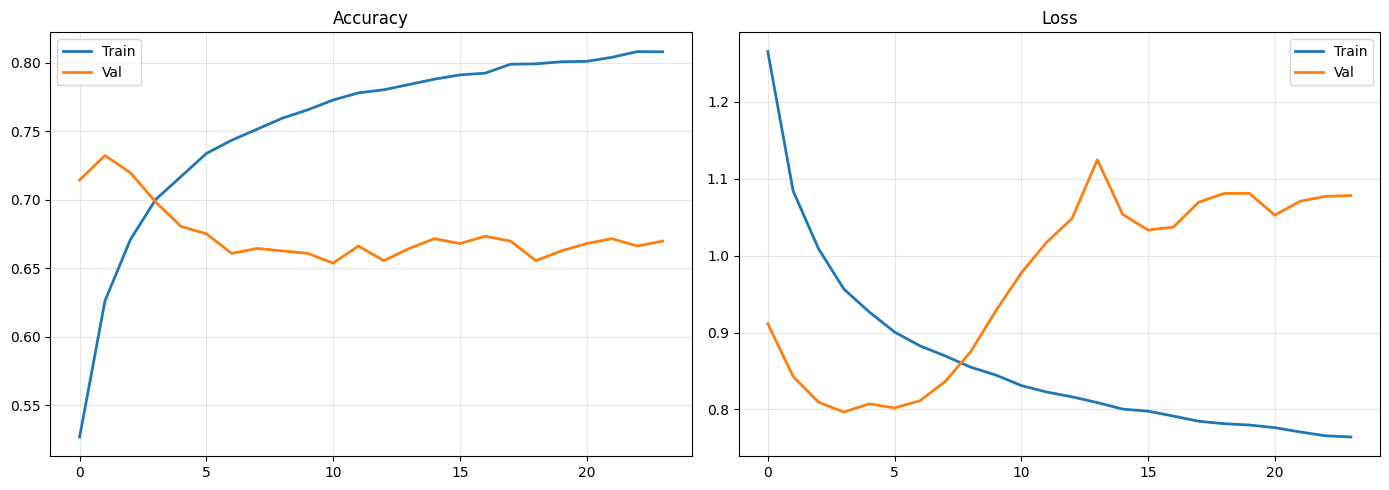

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history.history['accuracy'],     label='Train', lw=2)
axes[0].plot(history.history['val_accuracy'], label='Val',   lw=2)
axes[0].set_title('Accuracy'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(history.history['loss'],         label='Train', lw=2)
axes[1].plot(history.history['val_loss'],     label='Val',   lw=2)
axes[1].set_title('Loss');     axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,'training_curves.png'), dpi=150)
plt.show()


## Cell 12 — Evaluation + confusion matrix

                   precision    recall  f1-score   support

Incorrect Posture     0.8065    0.3472    0.4854        72
  Legs too Narrow     0.8763    1.0000    0.9341        85
    Legs too Wide     0.7500    0.8182    0.7826        99
      Not a Squat     0.6792    0.4675    0.5538        77
   Perfect Squats     0.7000    0.8750    0.7778       176

         accuracy                         0.7485       509
        macro avg     0.7624    0.7016    0.7067       509
     weighted avg     0.7511    0.7485    0.7296       509



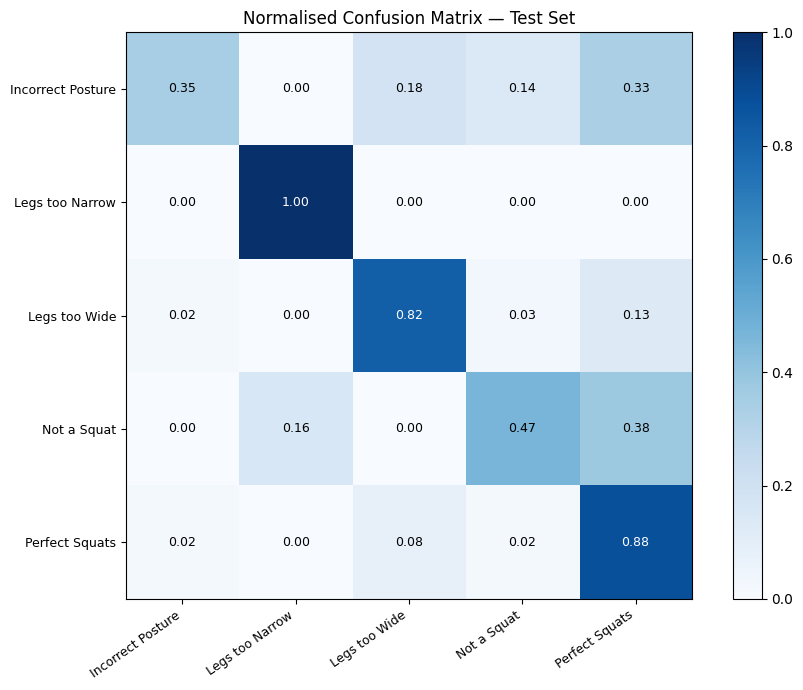

In [ ]:
keras.config.enable_unsafe_deserialization()
best_model = keras.models.load_model(os.path.join(OUTPUT_DIR, 'best_model.keras'))
y_pred     = np.argmax(best_model.predict(X_test, verbose=0), axis=1)

print(classification_report(y_test, y_pred, target_names=CLASS_NAMES, digits=4))

cm = confusion_matrix(y_test, y_pred, normalize='true')
fig, ax = plt.subplots(figsize=(9,7))
im = ax.imshow(cm, cmap='Blues', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, fraction=0.046)
ax.set_xticks(range(NUM_CLASSES)); ax.set_yticks(range(NUM_CLASSES))
ax.set_xticklabels(CLASS_NAMES, rotation=35, ha='right', fontsize=9)
ax.set_yticklabels(CLASS_NAMES, fontsize=9)
for i,j in itertools.product(range(NUM_CLASSES), range(NUM_CLASSES)):
    ax.text(j,i,f'{cm[i,j]:.2f}', ha='center', va='center',
            color='white' if cm[i,j]>0.5 else 'black', fontsize=9)
ax.set_title('Normalised Confusion Matrix — Test Set'); plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,'confusion_matrix.png'), dpi=150)
plt.show()


## Cell 13 — Export TFLite (quantised, mobile-ready)

In [ ]:
converter = tf.lite.TFLiteConverter.from_keras_model(best_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

def rep_data():
    for i in range(min(150, len(X_val))):
        yield [X_val[i:i+1].astype(np.float32)]
converter.representative_dataset = rep_data

# BiLSTM uses TensorList ops which need SELECT_TF_OPS to convert
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS,
    tf.lite.OpsSet.SELECT_TF_OPS
]
converter._experimental_lower_tensor_list_ops = False
converter.inference_input_type  = tf.float32
converter.inference_output_type = tf.float32

tflite_bytes = converter.convert()
TFLITE_PATH  = os.path.join(OUTPUT_DIR,'squat_classifier.tflite')
with open(TFLITE_PATH,'wb') as fh: fh.write(tflite_bytes)
print(f"TFLite saved → {TFLITE_PATH}  ({os.path.getsize(TFLITE_PATH)//1024} KB)")

Saved artifact at '/tmp/tmpblo3or4q'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 30, 56), dtype=tf.float32, name='landmark_window')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  133370954310736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133370954312464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133376210559888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133370954313232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133370954312656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133370954313040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133373436423888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133370954312272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133370954310928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133370954312080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133373436421776:

## Cell 14 — Inference engine setup
Run this before the live webcam cell. Initialises MediaPipe and the LiveEngine class.

In [ ]:
_mp_pose  = _mp_pose_module
_pose_det = _mp_pose_module.Pose(
    static_image_mode=False, model_complexity=1,
    smooth_landmarks=True,
    min_detection_confidence=0.45, min_tracking_confidence=0.45)

def _b64_to_numpy(b64: str) -> np.ndarray:
    if "," in b64: b64 = b64.split(",")[1]
    arr = np.frombuffer(b64decode(b64), dtype=np.uint8)
    return cv2.imdecode(arr, cv2.IMREAD_COLOR)

def _numpy_to_b64(bgr: np.ndarray, quality=70) -> str:
    _, buf = cv2.imencode(".jpg", bgr, [cv2.IMWRITE_JPEG_QUALITY, quality])
    return "data:image/jpeg;base64," + b64encode(buf).decode()

def _run_mediapipe(bgr):
    rgb     = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    results = _pose_det.process(rgb)
    ann     = bgr.copy()
    if results.pose_landmarks:
        _mp_drawing.draw_landmarks(
            ann, results.pose_landmarks,
            _mp_pose_module.POSE_CONNECTIONS,
            landmark_drawing_spec=_mp_styles.get_default_pose_landmarks_style())
        lm  = results.pose_landmarks.landmark
        raw = np.array([[lm[i].x,lm[i].y,lm[i].z,lm[i].visibility]
                        for i in KEPT_LM], dtype=np.float32)
        if raw[[L_HIP,R_HIP,L_KNEE,R_KNEE],3].min() >= 0.40:
            norm = normalise_skeleton(raw)
            return frame_to_feature(norm), norm, ann
    return None, None, ann

class LiveEngine:
    EMA_ALPHA   = 0.28
    CONF_THRESH = 0.50
    SQUAT_ANGLE = 130.

    def __init__(self):
        with open(os.path.join(OUTPUT_DIR,"scaler_params.json")) as f: sc = json.load(f)
        self.mean  = np.array(sc["mean"],  dtype=np.float32)
        self.scale = np.array(sc["scale"], dtype=np.float32)
        self.interp = tf.lite.Interpreter(model_path=TFLITE_PATH)
        self.interp.allocate_tensors()
        self.inp_d  = self.interp.get_input_details()
        self.out_d  = self.interp.get_output_details()
        self.buffer    = []
        self.ema_probs = np.ones(NUM_CLASSES, np.float32) / NUM_CLASSES
        self.state     = "IDLE"
        self.rep_count = 0

    def _scale(self, win):
        flat = win.reshape(1,-1)
        return ((flat - self.mean) / self.scale).reshape(1, WINDOW_SIZE, FEAT_DIM)

    def step(self, bgr):
        feat, norm, ann = _run_mediapipe(bgr)
        if feat is None:
            return "No pose detected", 0., self.state, self.rep_count, ann
        self.buffer.append(feat)
        if len(self.buffer) > WINDOW_SIZE: self.buffer.pop(0)
        if len(self.buffer) < WINDOW_SIZE:
            return f"Buffering  {len(self.buffer)}/{WINDOW_SIZE}", 0., self.state, self.rep_count, ann
        win    = np.stack(self.buffer)
        scaled = self._scale(win)
        self.interp.set_tensor(self.inp_d[0]["index"], scaled)
        self.interp.invoke()
        probs = self.interp.get_tensor(self.out_d[0]["index"])[0]
        self.ema_probs = self.EMA_ALPHA * probs + (1-self.EMA_ALPHA) * self.ema_probs
        top_idx  = int(np.argmax(self.ema_probs))
        top_conf = float(self.ema_probs[top_idx])
        knee_ang = (angle_between(vec3(norm,L_HIP), vec3(norm,L_KNEE), vec3(norm,L_ANKLE)) +
                    angle_between(vec3(norm,R_HIP), vec3(norm,R_KNEE), vec3(norm,R_ANKLE))) / 2.
        if   self.state=="IDLE"      and knee_ang < self.SQUAT_ANGLE:       self.state="SQUATTING"
        elif self.state=="SQUATTING" and knee_ang > self.SQUAT_ANGLE + 15:  self.state="COMPLETE"; self.rep_count+=1
        elif self.state=="COMPLETE":                                         self.state="IDLE"
        label = CLASS_NAMES[top_idx] if top_conf >= self.CONF_THRESH else "Positioning..."
        return label, top_conf, self.state, self.rep_count, ann

    def reset(self):
        self.buffer.clear()
        self.ema_probs[:] = 1./NUM_CLASSES
        self.state = "IDLE"; self.rep_count = 0

print("LiveEngine ready ✓")


LiveEngine ready ✓


## Cell 15 — 🔴 LIVE WEBCAM TEST
Click **▶ START**, allow camera access, and start squatting!

- Skeleton is drawn on your video feed by MediaPipe
- Label + confidence bar update in real-time
- 5 probability bars show all class scores
- Rep counter driven by knee-angle state machine
- Click **↺ Reset reps** to zero the counter

In [ ]:
_engine = None

def _live_start():
    global _engine
    _engine = LiveEngine()
    print("  ▶ Live inference started")

def _live_stop():
    global _engine
    _engine = None
    print("  ■ Stopped")

def _live_reset():
    if _engine: _engine.reset()

def _live_frame(b64: str):
    if _engine is None: return
    bgr = _b64_to_numpy(b64)
    if bgr is None: return
    label, conf, state, reps, ann = _engine.step(bgr)
    b64_out    = _numpy_to_b64(ann, quality=65)
    probs_json = json.dumps(_engine.ema_probs.tolist())
    js = (f"window._squat_result("
          f"'{b64_out}','{label}',{conf:.4f},'{state}',{reps},'{probs_json}');")
    eval_js(js)

output.register_callback('live_start', _live_start)
output.register_callback('live_stop',  _live_stop)
output.register_callback('live_reset', _live_reset)
output.register_callback('live_frame', _live_frame)

_LIVE_JS = """

(async () => {
const root = document.getElementById('squat-live');
if (!root) return;

root.innerHTML = `
<style>
  #squat-live * { box-sizing:border-box; font-family:'Courier New',monospace; }
  #squat-live {
    background: #07080f; color: #dde; border-radius: 14px;
    padding: 18px; max-width: 700px; border: 1px solid #1a1a2e;
  }
  .sl-header { display:flex; align-items:center; gap:10px; margin-bottom:14px; }
  .sl-logo {
    width:32px; height:32px; border-radius:8px;
    background: linear-gradient(135deg,#00e5ff,#7b2ff7);
    display:flex; align-items:center; justify-content:center; font-size:16px;
  }
  .sl-title { font-size:17px; font-weight:bold; color:#00e5ff; letter-spacing:2px; }
  #sl-canvas {
    width:640px; height:480px; background:#0d0e1a; border-radius:10px;
    border:2px solid #1a1a2e; display:block; margin-bottom:14px;
  }
  .sl-panels { display:flex; gap:10px; margin-bottom:12px; }
  .sl-label-panel {
    flex:1; background:#0d0e1a; border:1px solid #1a1a2e;
    border-radius:10px; padding:14px 16px;
  }
  .sl-label-text { font-size:20px; font-weight:bold; margin-bottom:6px; transition:color .3s; }
  .sl-conf-row { display:flex; align-items:center; gap:8px; }
  .sl-conf-track { flex:1; height:5px; background:#1a1a2e; border-radius:3px; overflow:hidden; }
  .sl-conf-fill { height:100%; border-radius:3px; transition:width .25s ease,background .3s; }
  .sl-conf-pct { font-size:11px; color:#555; min-width:32px; }
  .sl-mini {
    background:#0d0e1a; border:1px solid #1a1a2e; border-radius:10px;
    padding:12px 16px; min-width:100px; text-align:center;
  }
  .sl-mini-val { font-size:32px; font-weight:bold; color:#00e5ff; font-variant-numeric:tabular-nums; }
  .sl-mini-key { font-size:9px; color:#444; letter-spacing:2px; margin-top:3px; }
  .sl-state-val { font-size:13px !important; margin-top:4px; }
  .sl-btn-row { display:flex; gap:10px; align-items:center; }
  #sl-btn {
    padding:11px 28px; border-radius:8px; border:none;
    font-size:13px; font-weight:bold; letter-spacing:1px;
    cursor:pointer; background:#00e5ff; color:#000; transition:.2s;
  }
  #sl-btn.on { background:#ff3b30; color:#fff; }
  #sl-btn:hover { opacity:.85; }
  #sl-reset {
    padding:11px 18px; border-radius:8px; border:1px solid #333;
    font-size:12px; cursor:pointer; background:transparent; color:#888;
  }
  #sl-reset:hover { border-color:#666; color:#ccc; }
  #sl-status { font-size:11px; color:#444; margin-top:8px; }
  .sl-bars { display:flex; gap:3px; align-items:flex-end; height:40px; margin-top:10px; }
  .sl-bar-wrap { flex:1; display:flex; flex-direction:column; align-items:center; gap:2px; }
  .sl-bar { width:100%; border-radius:3px 3px 0 0; transition:height .25s ease; min-height:2px; }
  .sl-bar-lbl { font-size:8px; color:#444; text-align:center; line-height:1.2; }
</style>
<div class="sl-header">
  <div class="sl-logo">⬡</div>
  <div class="sl-title">LIVE SQUAT CLASSIFIER</div>
</div>
<canvas id="sl-canvas" width="640" height="480"></canvas>
<div class="sl-panels">
  <div class="sl-label-panel">
    <div class="sl-label-text" id="sl-label">Waiting…</div>
    <div class="sl-conf-row">
      <div class="sl-conf-track"><div class="sl-conf-fill" id="sl-fill" style="width:0%"></div></div>
      <div class="sl-conf-pct" id="sl-pct">—</div>
    </div>
    <div class="sl-bars" id="sl-bars"></div>
  </div>
  <div class="sl-mini">
    <div class="sl-mini-val" id="sl-reps">0</div>
    <div class="sl-mini-key">REPS</div>
  </div>
  <div class="sl-mini">
    <div class="sl-mini-val sl-state-val" id="sl-state">IDLE</div>
    <div class="sl-mini-key">STATE</div>
  </div>
</div>
<div class="sl-btn-row">
  <button id="sl-btn">▶  START</button>
  <button id="sl-reset">↺ Reset reps</button>
</div>
<div id="sl-status">Camera not started.</div>
`;

const canvas  = document.getElementById('sl-canvas');
const ctx     = canvas.getContext('2d');
const btn     = document.getElementById('sl-btn');
const resetB  = document.getElementById('sl-reset');
const labelEl = document.getElementById('sl-label');
const fillEl  = document.getElementById('sl-fill');
const pctEl   = document.getElementById('sl-pct');
const repsEl  = document.getElementById('sl-reps');
const stateEl = document.getElementById('sl-state');
const statusEl= document.getElementById('sl-status');
const barsEl  = document.getElementById('sl-bars');

const CLASSES = ['Incorrect_Posture','Legs_too_Narrow','Legs_too_Wide','Not_a_Squat','Perfect_Squats'];
const SHORT   = ['Incorrect','Narrow','Wide','Not Squat','Perfect'];
const COLORS  = {
  'Perfect_Squats':'#4caf50', 'Incorrect_Posture':'#ff3b30',
  'Legs_too_Narrow':'#ff9800','Legs_too_Wide':'#e040fb',
  'Not_a_Squat':'#ffd740',   'Positioning...':'#607d8b',
  'Buffering':'#455a64',     'No pose detected':'#455a64',
};

CLASSES.forEach((cls, i) => {
  const wrap = document.createElement('div'); wrap.className='sl-bar-wrap';
  const bar  = document.createElement('div');
  bar.className='sl-bar'; bar.id='bar-'+i;
  bar.style.height='2px'; bar.style.background=COLORS[cls]||'#555';
  const lbl = document.createElement('div');
  lbl.className='sl-bar-lbl'; lbl.textContent=SHORT[i];
  wrap.appendChild(bar); wrap.appendChild(lbl);
  barsEl.appendChild(wrap);
});

window._squat_result = function(b64img, label, conf, state, reps, probsJson) {
  const img = new Image();
  img.onload = () => ctx.drawImage(img, 0, 0, canvas.width, canvas.height);
  img.src = b64img;
  const color = COLORS[label] || '#9e9e9e';
  labelEl.textContent = label; labelEl.style.color = color;
  fillEl.style.width  = (conf*100)+'%'; fillEl.style.background = color;
  pctEl.textContent   = (conf*100).toFixed(0)+'%';
  repsEl.textContent  = reps;
  stateEl.textContent = state;
  const probs = JSON.parse(probsJson);
  probs.forEach((p,i) => {
    const bar = document.getElementById('bar-'+i);
    if (bar) bar.style.height = Math.max(2, p*38)+'px';
  });
};

let stream=null, interval=null, running=false;

btn.addEventListener('click', async () => {
  if (!running) {
    try {
      stream = await navigator.mediaDevices.getUserMedia({
        video:{width:{ideal:640},height:{ideal:480},facingMode:'user'}
      });
      const vid = document.createElement('video');
      vid.setAttribute('autoplay',''); vid.setAttribute('playsinline',''); vid.setAttribute('muted','');
      vid.srcObject = stream; await vid.play();
      running=true; btn.textContent='■  STOP'; btn.classList.add('on');
      statusEl.textContent='🔴 Live — perform a squat!';
      google.colab.kernel.invokeFunction('live_start', [], {});
      const tmp=document.createElement('canvas'); tmp.width=320; tmp.height=240;
      const tc=tmp.getContext('2d');
      interval = setInterval(() => {
        tc.drawImage(vid,0,0,320,240);
        const b64=tmp.toDataURL('image/jpeg',0.65);
        google.colab.kernel.invokeFunction('live_frame',[b64],{});
      }, 120);
    } catch(e) { statusEl.textContent='✗ Camera: '+e.message; }
  } else {
    running=false; clearInterval(interval);
    if(stream) stream.getTracks().forEach(t=>t.stop());
    btn.textContent='▶  START'; btn.classList.remove('on');
    statusEl.textContent='Stopped.';
    google.colab.kernel.invokeFunction('live_stop',[],{});
  }
});
resetB.addEventListener('click', () => {
  google.colab.kernel.invokeFunction('live_reset',[],{});
  repsEl.textContent='0';
});
})();
"""

display(HTML('<div id="squat-live"></div>'))
display(Javascript(_LIVE_JS))
